# Logistic Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Now from the data printed we can observe the columns are separated with thw help of ':' instaed os space so we will adjust that according to that usind 'sep'

In [ ]:
dataset=pd.read_csv("/content/bank-additional-full-1 (1) (1).csv",sep=';')
dataset

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


1- Age- Customer's age

2- Job- Job of customer

3- Marital- Marital status - i.e - married/unmarried..

4- education- Education level

5- default- Has the person failed to repay a loan before? , i.e- Bad credit history or not

6- housing- Does the person have a home loan?

7- loan- Does the person have any personal loan?

8- contact- How the bank contacted the person i.e- cellular, telephone

9- month- Month when contact happened

10- day_of_week- Day of the week

11- duration- Duration of the call (in seconds)

12- campaign- Number of contacts made to this person in this campaign

13- pdays- Days since the person was last contacted

14- previous- Number of contacts before this campaign

15- poutcome- Result of previous campaign

16- emp.var.rate (employment variation rate)- Economic indicator

17- cons.price.idx (consumer price index)- Measures inflation

18- cons.conf.idx (consumer confidence index)- How confident people feel about economy

19- euribor3m- Interest rate (Euro interbank rate - 3 months)

20- nr.employed- Number of employees in the economy

21- y (Target variable)- Final result

In [ ]:
dataset.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
dataset.shape

(41199, 21)

In [ ]:
dataset.sample()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
20910,30.0,self-employed,married,university.degree,no,yes,yes,cellular,aug,thu,...,1.0,999.0,0.0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [ ]:
dataset.isnull().sum()

,0
age,4
job,5
marital,5
education,5
default,4
housing,3
loan,4
contact,4
month,3
day_of_week,3


In [ ]:
dataset.duplicated().sum()

np.int64(15)

In [ ]:
dataset['job'].value_counts()

,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1726
entrepreneur,1456
self-employed,1421
housemaid,1060


In [ ]:
dataset['education'].value_counts()

,count
education,
university.degree,12168
high.school,9515
basic.9y,6045
professional.course,5249
basic.4y,4176
basic.6y,2292
unknown,1731
illiterate,18


In [ ]:
#As we have total 15-16 null values from 41199 rows we can esily drop them
dataset.dropna(inplace= True)

In [ ]:
dataset.isnull().sum().sum()

np.int64(0)

In [ ]:
#Removing the duplicate values
dataset.drop_duplicates(inplace=True)


In [ ]:
dataset.duplicated().sum()

np.int64(0)

In [ ]:
dataset.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000,41177.000000
mean,40.025111,258.315346,2.567890,962.465697,0.173033,0.081893,93.575749,-40.503113,3.621230,5167.029929
std,10.423948,259.302190,2.770286,186.934918,0.494975,1.570874,0.578862,4.628082,1.734463,72.257442
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# Checking For Outliers

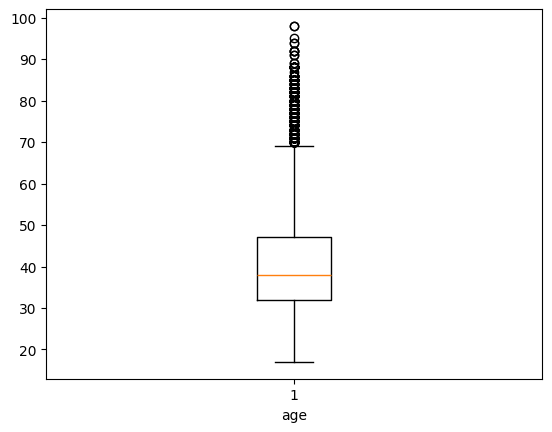

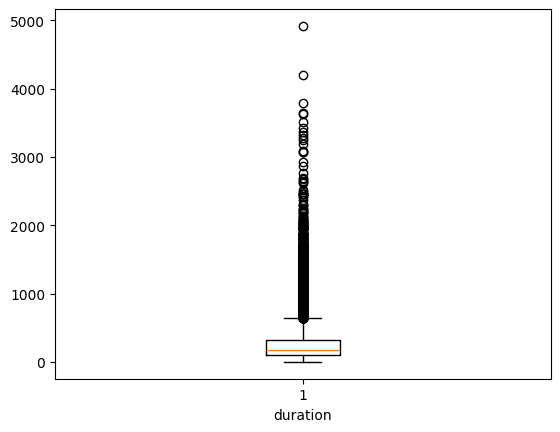

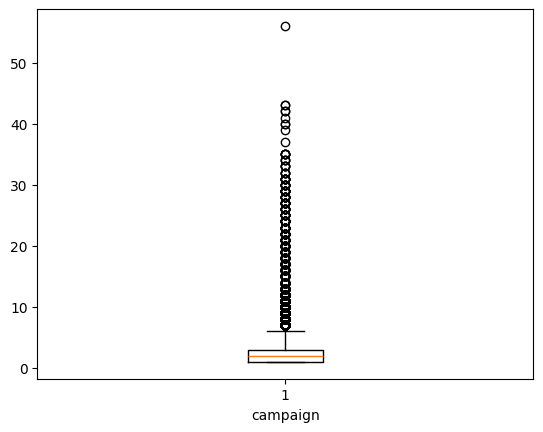

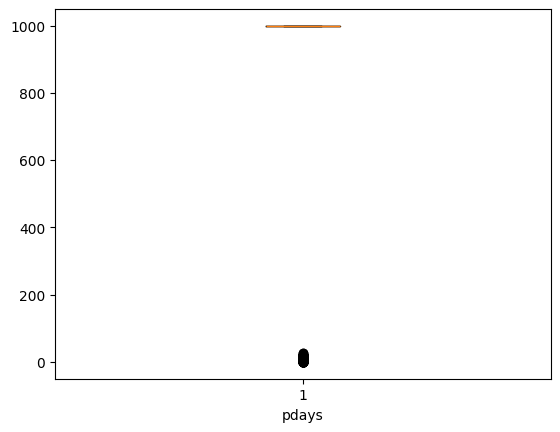

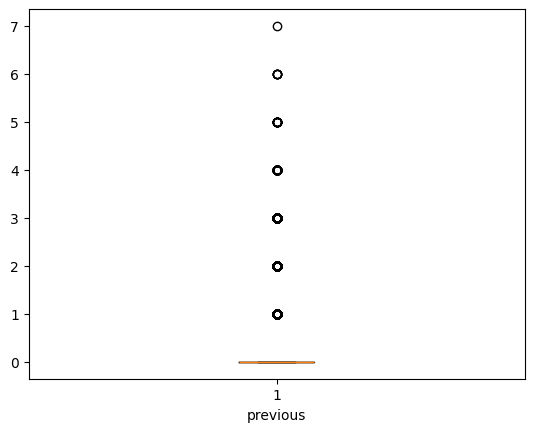

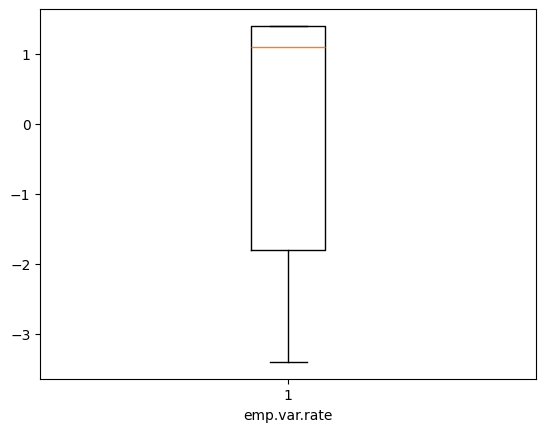

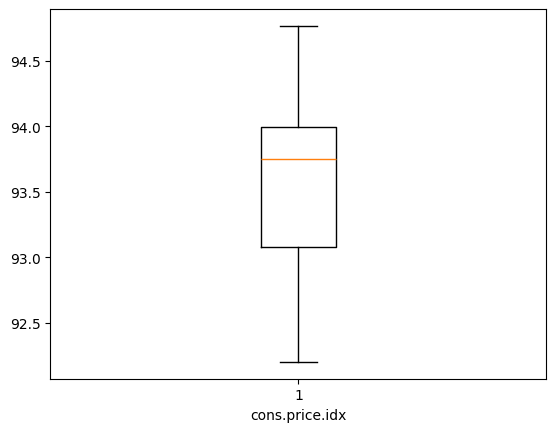

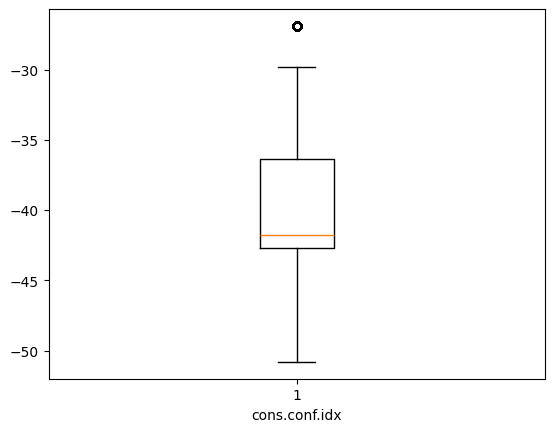

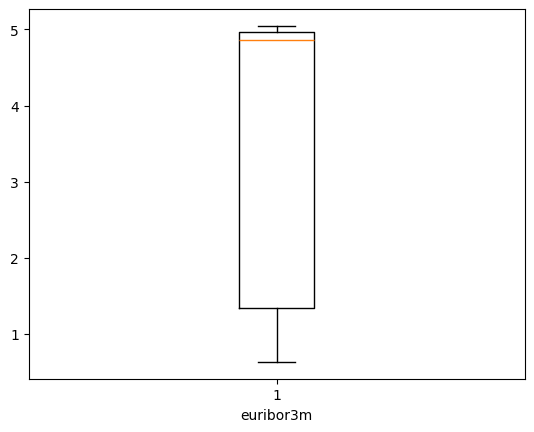

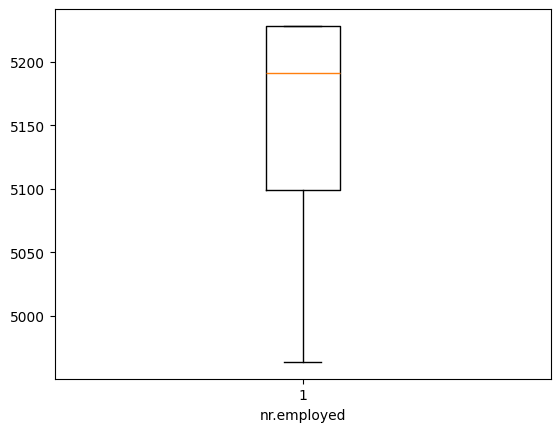

In [ ]:
for feature in dataset:
  if dataset[feature].dtype=='float64':
    plt.boxplot(dataset[feature])
    plt.xlabel(feature)
    plt.show()

with the reference of the above boxplot we can observe that some columns have outliers-

1- age - there are outliers

2- duration - there are outliers

3- campaign - there are outliers

4- pdays - there are no outliers - no box means no oultliers

5- previous - there are no outliers - no box no outliers

6- emp.var.rate - there are no outliers

7- cons.price.idx - there are no outliers

8- cons.conf.idx - there are outliers

9- nr.employeed - there are no outliers

In [ ]:
out_col=['age','campaign','cons.conf.idx']
for col in out_col:
  #Using IQR Range
  q1=dataset[col].quantile(0.25)
  q3=dataset[col].quantile(0.75)

  iqr=q3-q1
  lb=q1-(1.5*iqr)
  ub=q3+(1.5*iqr)


In [ ]:
lb

np.float64(-52.150000000000006)

In [ ]:
ub

np.float64(-26.949999999999992)

In [ ]:
#Now we just have to keeep the values which is in this ranfe of upper bound and lower bound.That is value should be greater than lower bound and lower than upper bound
dataset=dataset[(dataset[col]<=ub) & (dataset[col]>=lb)]

In [ ]:
dataset

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,46.0,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56.0,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44.0,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no


# Now since we need to classify the final tagrt value column is in 'yes' ot 'no' so we need to encode it in 1 and 0 format where 1 is for 'yes' and 0 is for 'no'. Instead of actually doing legit encoding we are gonna put the use of where function available in numpy!!!

In [ ]:
dataset['y']=np.where(dataset['y']=='yes',1,0)

/tmp/ipykernel_3566/1539601584.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['y']=np.where(dataset['y']=='yes',1,0)


In [ ]:
dataset

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,46.0,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56.0,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44.0,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1.0,999.0,0.0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1
41187,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,0


Encoding?

In machine learning models works only with numeric data. So we need to convert text data to numbers . The process of converting text to numbers is known as encoding

Label Encoding- used when we have 2 categories or data is in order

how it works?
-1- find unique values

-2- sort them alphabetically

-3- assign them numbers starting from 0

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder

In [ ]:
encoders = {}

for feature in dataset.columns:
  if dataset[feature].dtype=='object':
    le = LabelEncoder()
    dataset[feature]=le.fit_transform(dataset[feature])
    encoders[feature]=le # store encoded values

/tmp/ipykernel_3566/343580004.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[feature]=le.fit_transform(dataset[feature])
/tmp/ipykernel_3566/343580004.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[feature]=le.fit_transform(dataset[feature])
/tmp/ipykernel_3566/343580004.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

In [ ]:
encoders['job']

LabelEncoder()

In [ ]:
encoders['job'].classes_

array(['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management',
       'retired', 'self-employed', 'services', 'student', 'technician',
       'unemployed', 'unknown'], dtype=object)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40731 entries, 0 to 41193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             40731 non-null  float64
 1   job             40731 non-null  int64  
 2   marital         40731 non-null  int64  
 3   education       40731 non-null  int64  
 4   default         40731 non-null  int64  
 5   housing         40731 non-null  int64  
 6   loan            40731 non-null  int64  
 7   contact         40731 non-null  int64  
 8   month           40731 non-null  int64  
 9   day_of_week     40731 non-null  int64  
 10  duration        40731 non-null  float64
 11  campaign        40731 non-null  float64
 12  pdays           40731 non-null  float64
 13  previous        40731 non-null  float64
 14  poutcome        40731 non-null  int64  
 15  emp.var.rate    40731 non-null  float64
 16  cons.price.idx  40731 non-null  float64
 17  cons.conf.idx   40731 non-null  floa

In [ ]:
#Understanding correlation
corr_matrix=dataset.corr()
corr_matrix

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
age,1.000000,-0.001080,-0.389483,-0.113874,0.168933,-0.001415,-0.006268,0.010280,-0.035488,-0.020458,...,0.006891,-0.031447,0.020875,0.019587,0.013249,0.013382,0.119106,0.021089,-0.006043,0.027371
job,-0.001080,1.000000,0.028532,0.136926,-0.027757,0.007493,-0.010814,-0.023993,-0.036882,-0.000664,...,-0.006116,-0.027600,0.020893,0.010910,-0.004289,-0.012608,0.049746,-0.004911,-0.016206,0.022704
marital,-0.389483,0.028532,1.000000,0.108082,-0.079047,0.010992,0.005749,-0.054690,-0.009853,0.003818,...,-0.006743,-0.039342,0.038886,0.003323,-0.084098,-0.056490,-0.039592,-0.091668,-0.086010,0.044565
education,-0.113874,0.136926,0.108082,1.000000,-0.187683,0.016661,0.006095,-0.106699,-0.085887,-0.018755,...,0.000883,-0.048222,0.039057,0.018948,-0.043235,-0.082032,0.080601,-0.035678,-0.040926,0.058175
default,0.168933,-0.027757,-0.079047,-0.187683,1.000000,-0.015994,-0.004444,0.133744,-0.008073,-0.007850,...,0.031121,0.079370,-0.100769,0.022793,0.198331,0.162300,0.042915,0.190582,0.184587,-0.097546
housing,-0.001415,0.007493,0.010992,0.016661,-0.015994,1.000000,0.044498,-0.083429,-0.018552,0.002590,...,-0.011351,-0.009982,0.022857,-0.013684,-0.062064,-0.082555,-0.035931,-0.060398,-0.047113,0.012387
loan,-0.006268,-0.010814,0.005749,0.006095,-0.004444,0.044498,1.000000,-0.009023,-0.004398,-0.009454,...,0.004832,-0.001209,-0.000363,-0.001295,-0.000116,-0.004359,-0.009900,-0.001355,0.002172,-0.003391
contact,0.010280,-0.023993,-0.054690,-0.106699,0.133744,-0.083429,-0.009023,1.000000,0.290682,-0.009498,...,0.075450,0.116009,-0.211589,0.120794,0.393903,0.595934,0.282365,0.398465,0.265342,-0.141610
month,-0.035488,-0.036882,-0.009853,-0.085887,-0.008073,-0.018552,-0.004398,0.290682,1.000000,0.027120,...,-0.056299,-0.036874,0.093939,-0.066213,-0.145333,0.032212,-0.045645,-0.090332,-0.191895,-0.023174
day_of_week,-0.020458,-0.000664,0.003818,-0.018755,-0.007850,0.002590,-0.009454,-0.009498,0.027120,1.000000,...,-0.037887,-0.009318,-0.004625,0.018550,0.035913,0.007076,0.041804,0.041028,0.030738,0.016350


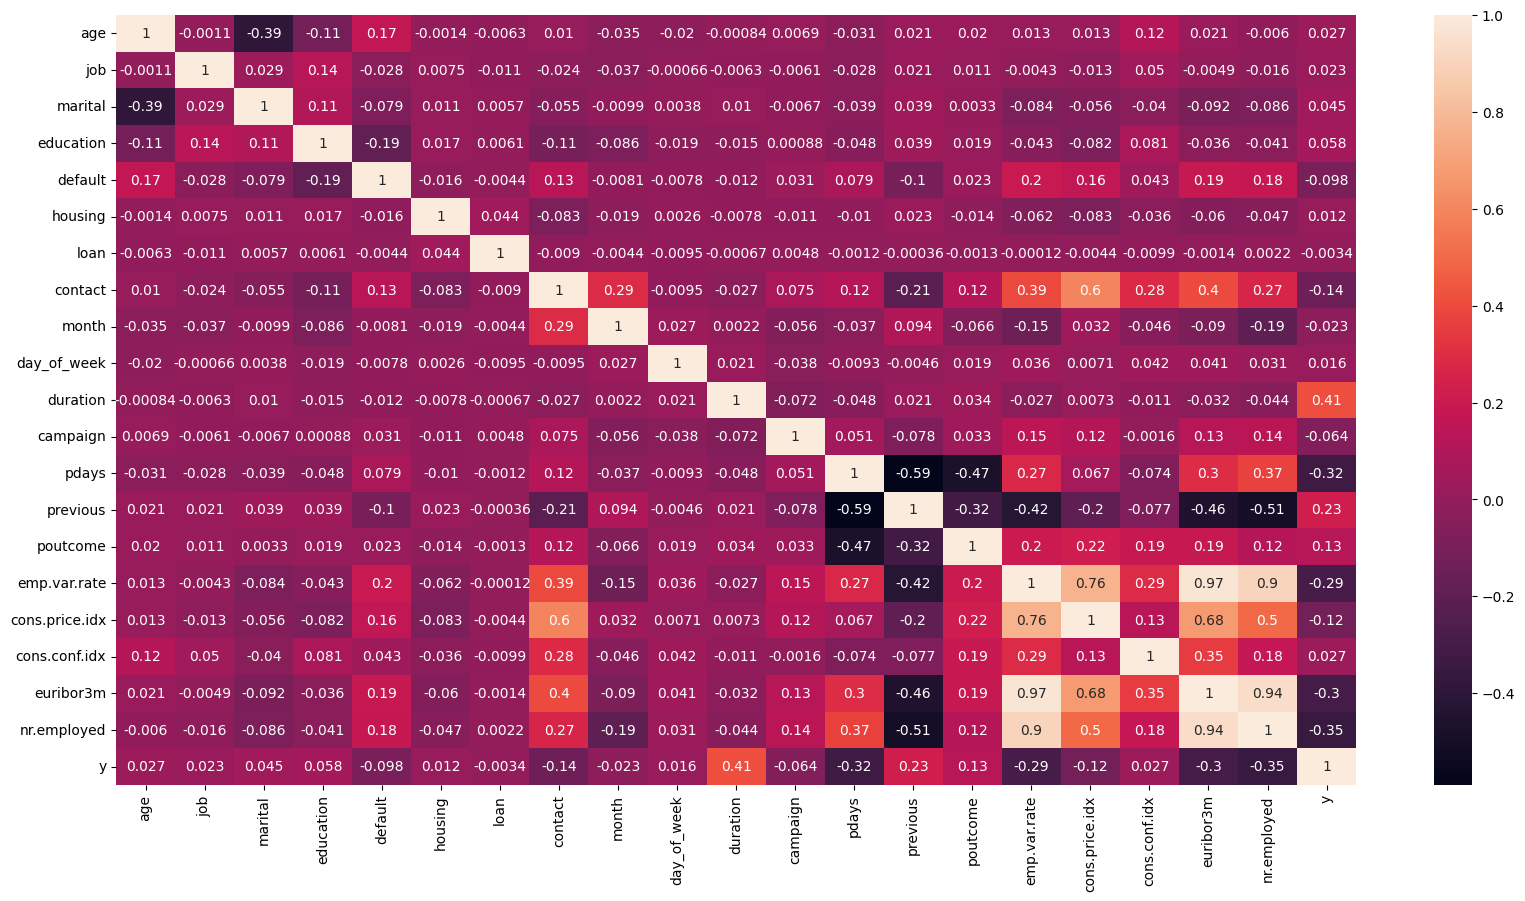

In [ ]:
#Visualisation of corr matrix would be
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix,annot=True)
plt.show()

# VIF Method

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
col_list=[]
for i in dataset.columns:
  if ((dataset[i].dtype!=object) & (i!='y')):
    col_list.append(i)


X=dataset[col_list]
Vif_data=pd.DataFrame()
Vif_data['Columnn_name']=X.columns
Vif_data['Column_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns))]


In [ ]:
Vif_data

,Columnn_name,Column_values
0,age,20.000026
1,job,2.116836
2,marital,5.640953
3,education,4.471495
4,default,1.406251
5,housing,2.206095
6,loan,1.208298
7,contact,2.888792
8,month,6.659115
9,day_of_week,3.082905


In [ ]:
# VIF SCORE VALUE --- 1 ----(no multicolinarity)
# 1-5 --------------(low multicolinearity)
# 5 or gretear than 5 ----------------(high multicolinearity)

In [ ]:
#currently we have vif score of nr.employed as the maximum
dataset=dataset.drop('nr.employed',axis=1)

KeyError: "['nr.employed'] not found in axis"

In [ ]:
col_list=[]
for i in dataset:
  if((dataset[i].dtype!='object') & (i!='y')):
    col_list.append(i)

X=dataset[col_list]
Vif_data=pd.DataFrame()
Vif_data['Column_name']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns))]


In [ ]:
Vif_data

,Column_name,Vif_values
0,age,19.948544
1,job,2.116614
2,marital,5.639827
3,education,4.470836
4,default,1.402993
5,housing,2.205679
6,loan,1.208235
7,contact,2.426418
8,month,5.714330
9,day_of_week,3.082510


In [ ]:
#Again repeating same procedure

In [ ]:
dataset=dataset.drop('cons.price.idx',axis=1)

In [ ]:
col_list=[]
for i in dataset:
  if((dataset[i].dtype!='object') & (i!='y')):
    col_list.append(i)

X=dataset[col_list]
Vif_data=pd.DataFrame()
Vif_data['Column_name']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns))]


In [ ]:
Vif_data

,Column_name,Vif_values
0,age,18.770550
1,job,2.110914
2,marital,5.495443
3,education,4.420257
4,default,1.402979
5,housing,2.204181
6,loan,1.207823
7,contact,2.336361
8,month,5.665847
9,day_of_week,3.067854


In [ ]:
dataset=dataset.drop('pdays',axis=1)

In [ ]:
col_list=[]
for i in dataset:
  if((dataset[i].dtype!='object') & (i!='y')):
    col_list.append(i)

X=dataset[col_list]
Vif_data=pd.DataFrame()
Vif_data['Column_name']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns))]


In [ ]:
Vif_data

,Column_name,Vif_values
0,age,17.787693
1,job,2.107574
2,marital,5.376501
3,education,4.368674
4,default,1.402962
5,housing,2.201098
6,loan,1.207747
7,contact,2.272505
8,month,5.617107
9,day_of_week,3.056453


In [ ]:
dataset=dataset.drop('euribor3m',axis=1)


In [ ]:
col_list=[]
for i in dataset:
  if((dataset[i].dtype!='object') & (i!='y')):
    col_list.append(i)

X=dataset[col_list]
Vif_data=pd.DataFrame()
Vif_data['Column_name']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns))]


In [ ]:
Vif_data

,Column_name,Vif_values
0,age,15.273710
1,job,2.101736
2,marital,5.185168
3,education,4.203819
4,default,1.402802
5,housing,2.193281
6,loan,1.207369
7,contact,2.262052
8,month,5.241473
9,day_of_week,3.018466


In [ ]:
dataset=dataset.drop('cons.conf.idx',axis=1)

In [ ]:
col_list=[]
for i in dataset:
  if((dataset[i].dtype!='object') & (i!='y')):
    col_list.append(i)

X=dataset[col_list]
Vif_data=pd.DataFrame()
Vif_data['Column_name']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns))]


In [ ]:
Vif_data

,Column_name,Vif_values
0,age,9.839499
1,job,2.093525
2,marital,4.264339
3,education,4.065843
4,default,1.400548
5,housing,2.153565
6,loan,1.203693
7,contact,2.239610
8,month,4.783782
9,day_of_week,2.949474


In [ ]:
dataset=dataset.drop('age',axis=1, errors='ignore')

In [ ]:
col_list=[]
for i in dataset:
  if((dataset[i].dtype!='object') & (i!='y')):
    col_list.append(i)

X=dataset[col_list]
Vif_data=pd.DataFrame()
Vif_data['Column_name']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns))]


In [ ]:
Vif_data

,Column_name,Vif_values
0,job,2.060950
1,marital,4.250289
2,education,3.903981
3,default,1.319667
4,housing,2.100017
5,loan,1.200025
6,contact,2.237971
7,month,4.510831
8,day_of_week,2.852789
9,duration,1.938318


In [ ]:
dataset=dataset.drop('poutcome',axis=1)


In [ ]:
col_list=[]
for i in dataset:
  if((dataset[i].dtype!='object') & (i!='y')):
    col_list.append(i)

X=dataset[col_list]
Vif_data=pd.DataFrame()
Vif_data['Column_name']=X.columns
Vif_data['Vif_values']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns))]


In [ ]:
Vif_data

,Column_name,Vif_values
0,job,2.033830
1,marital,3.986173
2,education,3.639115
3,default,1.305687
4,housing,2.058340
5,loan,1.196985
6,contact,2.221511
7,month,4.334887
8,day_of_week,2.741568
9,duration,1.879325


# Model Buiding

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from pandas.core.common import random_state
y = dataset['y']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=34)

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [ ]:
from sklearn.metrics import*
print(accuracy_score(y_test,y_pred))

0.9013133668835154
